<a href="https://colab.research.google.com/github/JaderBarbosaLSU/wellbore-thermal-storage/blob/main/Pareto_for_THUMS_DoE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

File loaded successfully!
Shape: (136, 32)

KPIs used: ['weighted_RTE', 'RTE_real', 'm_m_eff', 'final_energy_output', 'DE_per_well_eff_kWh', 'rank_eff', 'net_rank_eff']

Top factors overall:
        factor      mean
0        T_m_C  0.762784
8          r_e  0.572605
14    T_sink_C  0.482464
6        k_m_l  0.449776
12    DT_3C_2C  0.352638
13       N_lay  0.343495
2      rho_m_l  0.312145
15  T_source_C  0.282863
11        t_ch  0.265425
7          h_m  0.165540


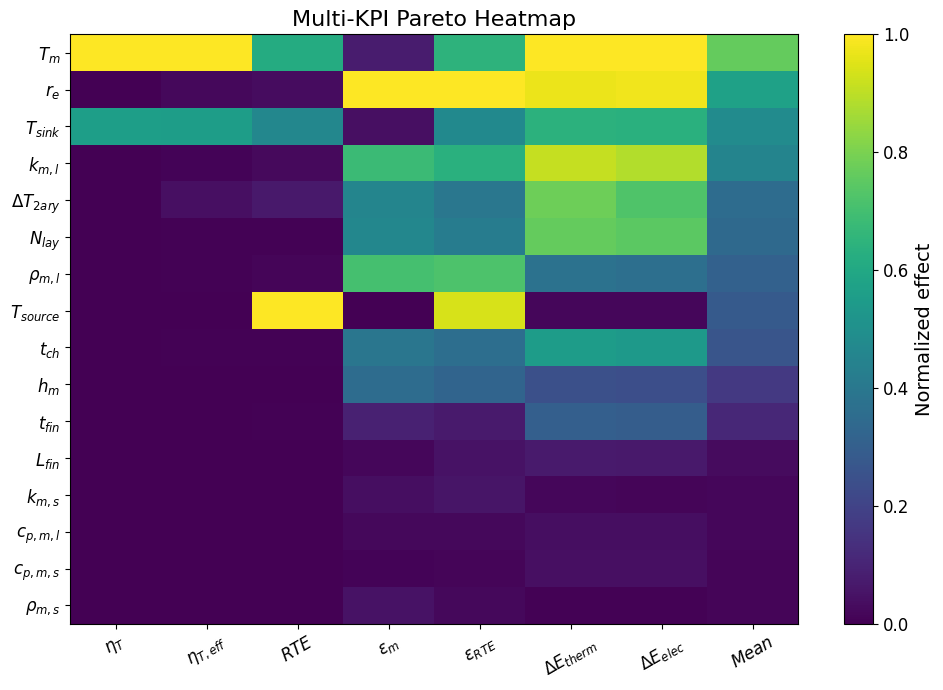

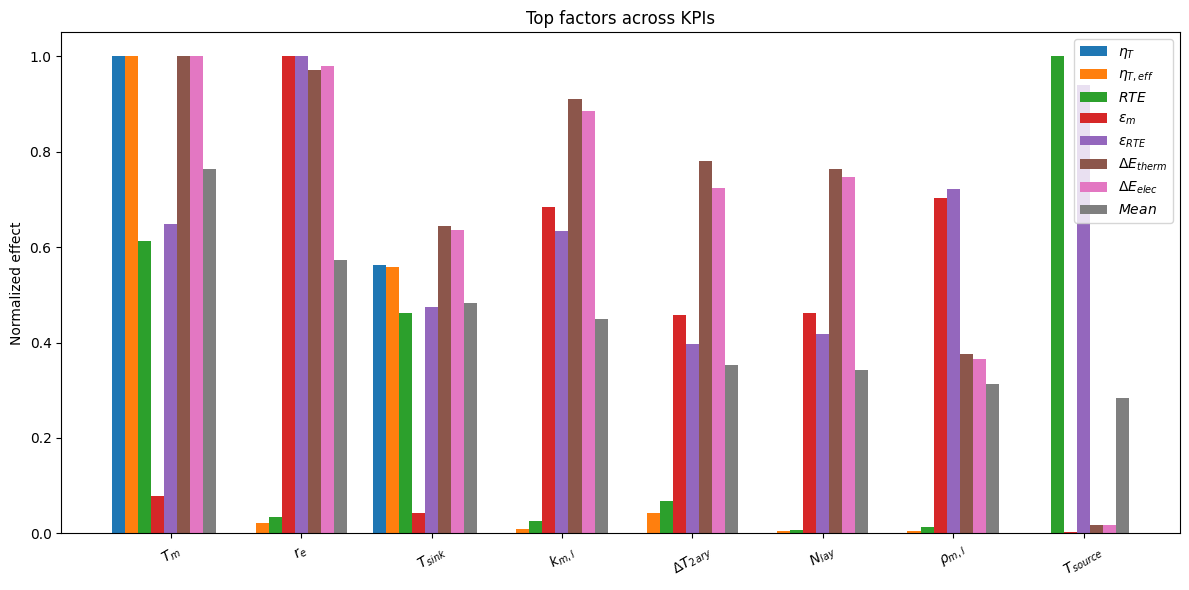

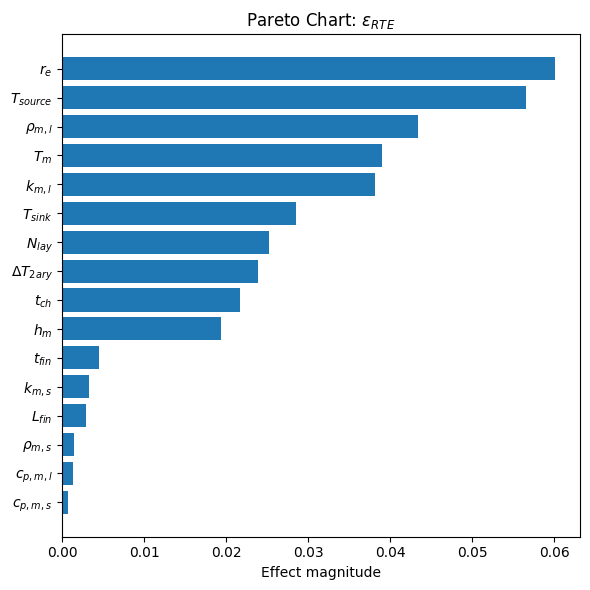

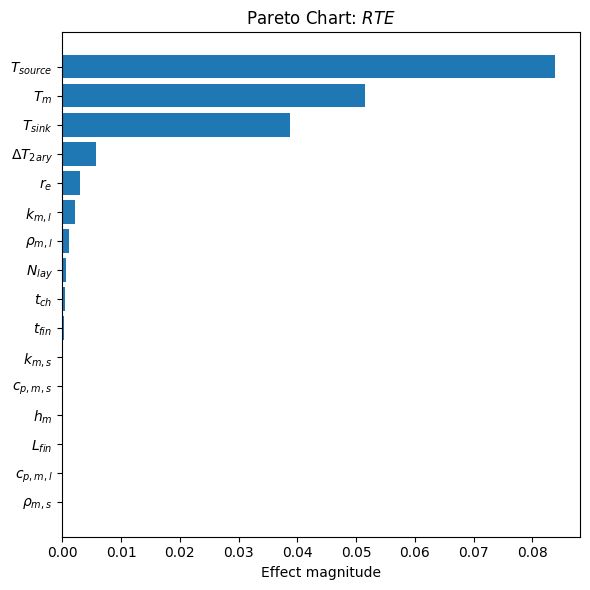

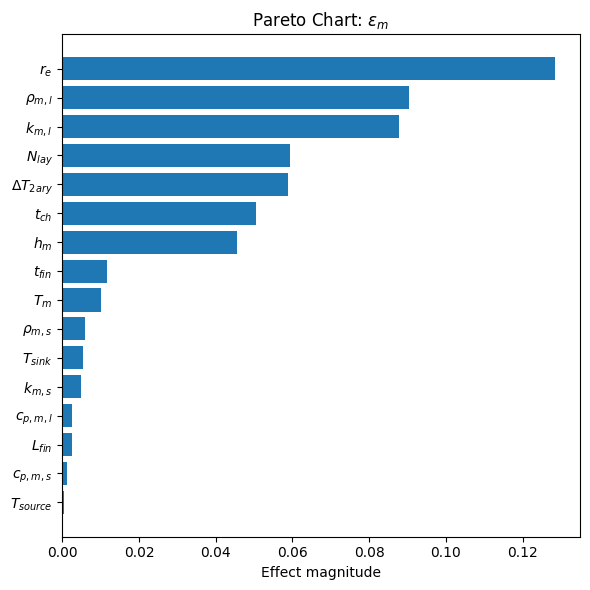

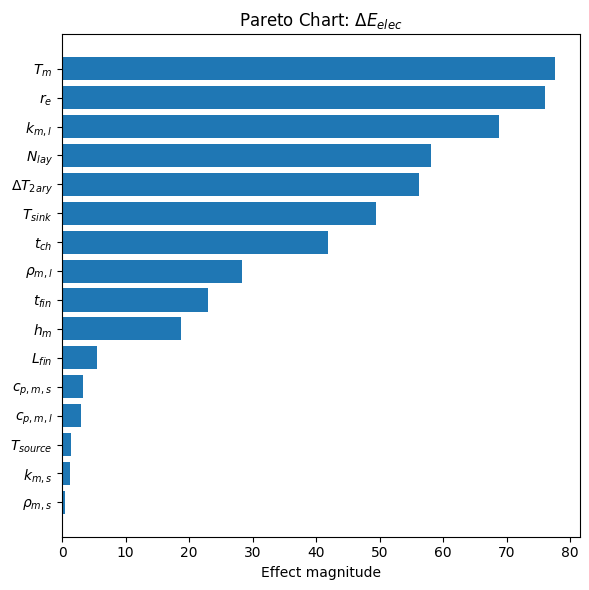

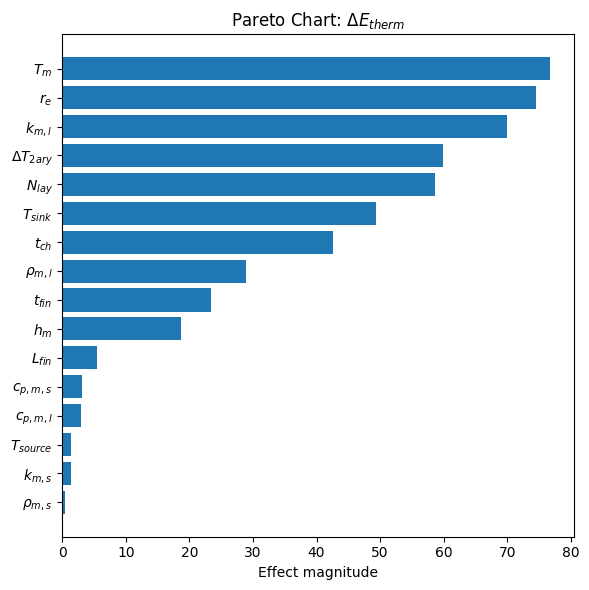

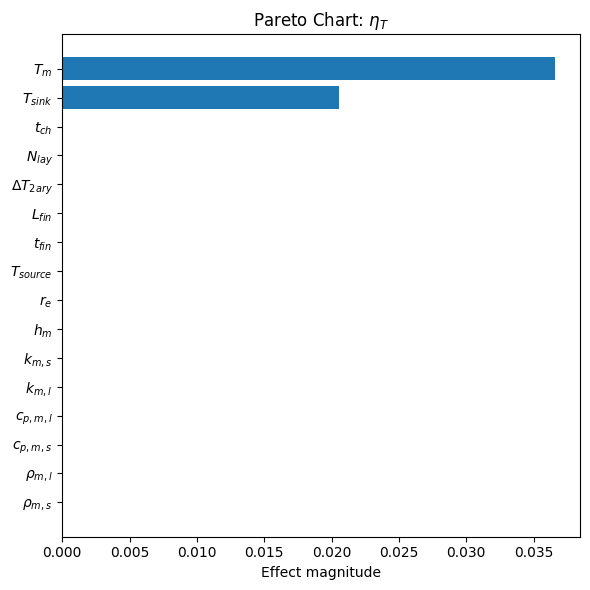

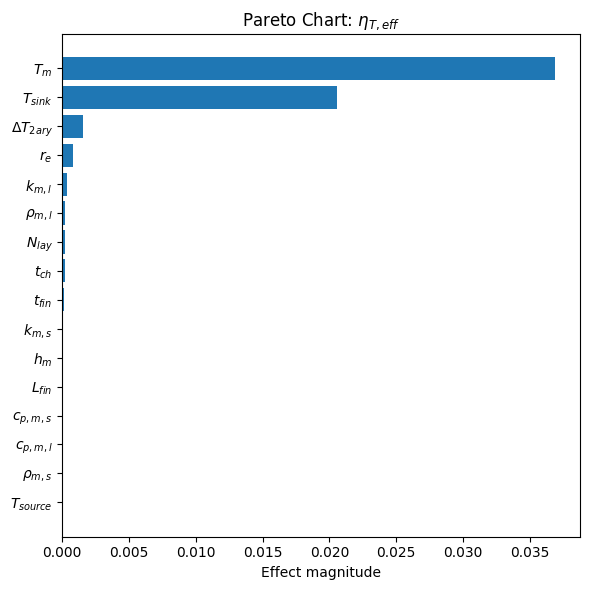

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Disable LaTeX rendering as it caused an error due to missing LaTeX installation
plt.rcParams['text.usetex'] = False

# ------------------------------------------------------------
# 1. Read your file
# ------------------------------------------------------------

file_name = "borehole_battery_D16_128FF_with_centers.csv"
df = pd.read_csv(file_name)

print("File loaded successfully!")
print("Shape:", df.shape)

# ------------------------------------------------------------
# 2. Define factors and KPIs
# ------------------------------------------------------------

factor_names = [
    "T_m_C","rho_m_s","rho_m_l","cp_m_s","cp_m_l",
    "k_m_s","k_m_l","h_m","r_e","fin_t","fin_L",
    "t_ch","DT_3C_2C","N_lay","T_sink_C","T_source_C"
]

# Define display names for factors with proper subscripts for plotting
factor_display_names = {
    "T_m_C": r"$T_m$",
    "rho_m_s": r"$\rho_{m,s}$",
    "rho_m_l": r"$\rho_{m,l}$",
    "cp_m_s": r"$c_{p,m,s}$",
    "cp_m_l": r"$c_{p,m,l}$",
    "k_m_s": r"$k_{m,s}$",
    "k_m_l": r"$k_{m,l}$",
    "h_m": r"$h_m$",
    "r_e": r"$r_e$",
    "fin_t": r"$t_{fin}$",
    "fin_L": r"$L_{fin}$",
    "t_ch": r"$t_{ch}$",
    "DT_3C_2C": r"$\Delta T_{2ary}$",
    "N_lay": r"$N_{lay}$",
    "T_sink_C": r"$T_{sink}$",
    "T_source_C": r"$T_{source}$"
}

kpis = [
    "weighted_RTE",
    "RTE_real",
    "m_m_eff",
    "final_energy_output",
    "DE_per_well_eff_kWh",
    "rank_eff",
    "net_rank_eff",
]

kpis = [k for k in kpis if k in df.columns]

# Define display names for KPIs
kpi_display_names = {
    "weighted_RTE": r"$\epsilon_{RTE}$",
    "RTE_real": r"$RTE$",
    "m_m_eff": r"$\epsilon_m$",
    "final_energy_output": r"$\Delta E_{elec}$",
    "DE_per_well_eff_kWh": r"$\Delta E_{therm}$",
    "rank_eff": r"$\eta_T$",
    "net_rank_eff": r"$\eta_{T,eff}$",
    "mean": r"$Mean$"
}

print("\nKPIs used:", kpis)

# ------------------------------------------------------------
# 3. Compute main effects
# ------------------------------------------------------------

def compute_effects(df, response):
    effects = []
    for f in factor_names:
        low  = df[f].min()
        high = df[f].max()

        mean_low  = df[df[f] == low][response].mean()
        mean_high = df[df[f] == high][response].mean()

        effect = mean_high - mean_low

        effects.append({
            "factor": f,
            "effect": effect,
            "abs_effect": abs(effect)
        })

    return pd.DataFrame(effects)

effect_tables = {kpi: compute_effects(df, kpi) for kpi in kpis}

# ------------------------------------------------------------
# 4. Normalize for multi-KPI comparison
# ------------------------------------------------------------

comparison = pd.DataFrame({"factor": factor_names})

for kpi, eff in effect_tables.items():
    temp = eff.copy()
    max_val = temp["abs_effect"].max()

    temp[kpi] = temp["abs_effect"] / max_val if max_val > 0 else 0

    comparison = comparison.merge(temp[["factor", kpi]], on="factor")

comparison["mean"] = comparison[kpis].mean(axis=1)
comparison = comparison.sort_values("mean", ascending=False)
comparison["display_factor"] = comparison["factor"].map(factor_display_names)

print("\nTop factors overall:")
print(comparison[["factor", "mean"]].head(10))

# ------------------------------------------------------------
# 5. Heatmap (BEST FIGURE)
# ------------------------------------------------------------

# Create a list of KPIs to plot, including the mean
plot_kpis = ["rank_eff", "net_rank_eff", "RTE_real", "m_m_eff", "weighted_RTE", "DE_per_well_eff_kWh", "final_energy_output", "mean"]
plot_kpi_display_names = [kpi_display_names[k] for k in plot_kpis]
plot_df = comparison.set_index("display_factor")[plot_kpis]

plt.figure(figsize=(10,7))
im = plt.imshow(plot_df.values, aspect='auto') # Assign imshow to a variable to get colorbar
cbar = plt.colorbar(im, label="Normalized effect")
cbar.ax.tick_params(labelsize=12) # Font size for colorbar ticks
cbar.set_label("Normalized effect", fontsize=14) # Font size for colorbar label

plt.yticks(range(len(plot_df.index)), plot_df.index, fontsize=12)
plt.xticks(range(len(plot_kpi_display_names)), plot_kpi_display_names, rotation=30, fontsize=12)

plt.title("Multi-KPI Pareto Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Grouped bar chart (top factors)
# ------------------------------------------------------------

top_n = 8
top = comparison.head(top_n)

x = np.arange(top_n)
width = 0.8 / len(plot_kpis) # Use plot_kpis for width calculation

plt.figure(figsize=(12,6))

for i, kpi_internal_name in enumerate(plot_kpis):
    plt.bar(x + i*width, top[kpi_internal_name], width=width, label=kpi_display_names[kpi_internal_name])

plt.xticks(x + width*len(plot_kpis)/2, top["display_factor"], rotation=30)
plt.ylabel("Normalized effect")
plt.title("Top factors across KPIs")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Single KPI Pareto (optional)
# ------------------------------------------------------------

for kpi, eff in effect_tables.items():
    eff["display_factor"] = eff["factor"].map(factor_display_names)
    eff = eff.sort_values("abs_effect", ascending=True)

    plt.figure(figsize=(6,6))
    plt.barh(eff["display_factor"], eff["abs_effect"])
    plt.title(f"Pareto Chart: {kpi_display_names[kpi]}") # Use display name for title
    plt.xlabel("Effect magnitude")
    plt.tight_layout()
    plt.show()